# Converting Kerr-format file(s) to FITS 
Basic two: versions 'x' is 1-5 so far
* Pixel tables: `toby_vx.npz`
* Band description metadata: `toby_vx.pickle`

Adding related column(s) <br>
* 16-year exposure: `toby_exposure.npz`<br>
    I use it to compute counts from the spectral function

* Individual source counts per pixel: `toby_ptsrcs_vx.npz`<br>
  Should be indpendent of version, given that is the same list of sources<br>
  Columns:
  * names -- the FL16Y names of the catalog sources.  They are sub-ordered by spectral model, so all of the PowerLaw sources appear first, then LogParabola, then PLEC4
  * spectra -- this is a (nband=43,nsrc=7141) array giving the total counts in each band predicted for the FL16Y model values
  * entries_per_band -- (nband=43) array giving the total number of ps model counts for each band
  * pscounts -- (sum(entries_per_band)) array with the counts for each pixel for each point sources.
  * healpixidx -- the data HEALPixel index for the entries of pscounts (THIS IS WHAT IS WRONG -- it's the index into the array)
  * nameidx -- index into the names array identifying the source for each of the entries in the list
<br>
Within each band, the point source arrays are sorted by nameidx.

---
23 Aug 26
Implement addition of the total pointsource model, to column 'pointsource'

In [1]:
%reset -f
%run setup_notebook
%run pylib/tools dark date
from importlib import reload

<h5 style="text-align:right; margin-right:15px"> 2026-08-23 14:56</h5>

In [2]:
from like3 import kerr_pixel_table; reload(kerr_pixel_table)
from like3.kerr_pixel_table import KerrPixelTable, KerrPtsrcInfo
pt = KerrPixelTable('files/kerr/toby_v5','files/kerr/toby_exposure', toring=False)

srcinfo = KerrPtsrcInfo()
print('Source Information Summary:')
srcinfo.print_summary()

Loaded columns ['diffuse', 'extendedsources', 'sunmoon', 'counts', 'indices'] from files/kerr/toby_v5.npz
Loaded columns ['exposure'] from files/kerr/toby_exposure.npz
Read files/kerr/toby_ptsrcs_v5.npz:
	  --> columns ['names', 'spectra', 'entries_per_band', 'nameidx', 'healpixidx', 'pscounts'] 
	Total number of pixels: 18,265,372
Loaded meta data describing 43 bands from files/kerr/toby_v5.pickle
Source Information Summary:
Column name        Shape
names              (7141,)
spectra            (43, 7141)
entries_per_band   (43,)
nameidx            (18265372,)
healpixidx         (18265372,)
pscounts           (18265372,)

Totals:
entries per band: 18,265,372
pixels:           18,265,372
pscounts:         29,430,497
spectra sum:      29,640,128


In [ ]:
pt.process_point_sources( srcinfo, ); #outfile='files/kerr/pointsources.npz')
pt.to_fits('files/kerr/pixel_table_v5.fits')


Wrote FITS file to files/kerr/pixel_table_v5.fits


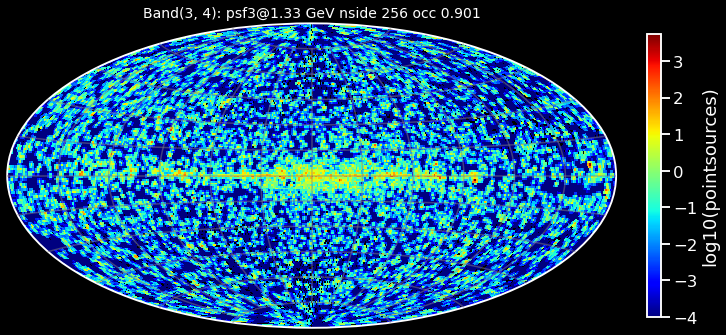

In [5]:
b = pt[(3,4)]
b.ait_plot('pointsources', colorbar=True, vmin=-4, cmap='jet', title=str(b));

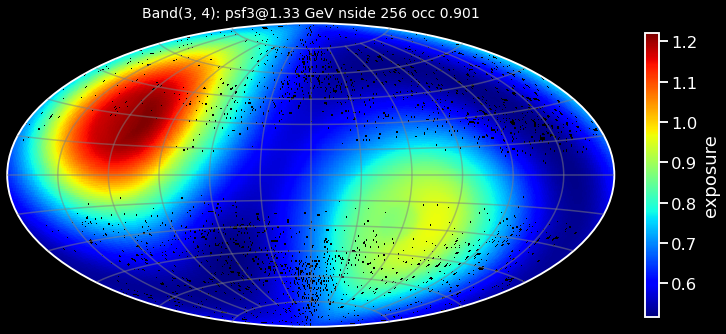

In [6]:
b.ait_plot(component='exposure', log=False,
         cmap='jet', title=str(b),colorbar=True);

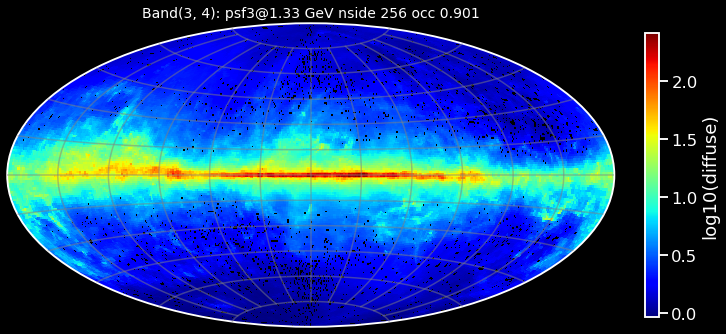

In [7]:
b.ait_plot(b.diffuse, name='diffuse', log=True,
         cmap='jet', title=str(b),colorbar=True);